# S&P 500 Options: IC Mechanism Diagnostic

This preview-only notebook studies the diagnostic 10-session delta-hedged label. It uses the
finalized financial feature artifact and constructs label-specific walk-forward folds directly
from the diagnostic label. Fold-scoped temporal estimates are deliberately excluded because their
geometry follows the return-to-expiry label.

The notebook examines feature ablation, lag decay, return decomposition, and training-only feature
dimensionality. It writes no registry rows, enters no official population, runs no backtest, and
cannot select or alter the return-to-expiry population.

In [1]:
"""Run validation-only mechanism diagnostics for the secondary option label."""

import numpy as np
import plotly.graph_objects as go
import polars as pl
from ml4t.diagnostic.metrics import compute_ic_uncertainty
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

from case_studies.sp500_options._ic_diagnostics import daily_ic
from case_studies.utils.artifact_digest import value_digest
from utils.cv_splits import select_folds
from utils.modeling import generate_cv_splits, prepare_cv_folds
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds

In [2]:
EXECUTION_TIER = "preview"
MAX_SYMBOLS = 0
MAX_FOLDS = 0
SEED = 42

CASE_STUDY = "sp500_options"
DIAGNOSTIC_LABEL = "fwd_ret_dh_10d"
UNHEDGED_LABEL = "fwd_ret_10d"
LABEL_BUFFER = "10D"

# How many names a date needs before its cross-sectional correlation is computed at all. One
# number, used by both IC computations below, because they measure the same quantity on the same
# panel and a reader compares them directly. They carried 5 and 20, neither explained, which made
# the two figures answer slightly different questions without saying so: a date with eight names
# contributed to one and not the other. Ten is the floor `04_model_based_features` screens its
# incremental features on, so the whole case study now reports IC over the same minimum
# cross-section. A rank correlation over fewer names is mostly the sampling noise of which names
# happened to quote that day.
MIN_SYMBOLS_PER_DATE = 10

## Financial features and label-specific folds

In [3]:
if EXECUTION_TIER != "preview":
    raise ValueError("the IC mechanism diagnostic is excluded from canonical execution")
set_global_seeds(SEED)
# Finalized features and labels are inputs, and `get_case_study_dir` is what finds them wherever
# they are. It resolves to ML4T_OUTPUT_DIR when one is set, which is where the stage 01-05
# artifacts live under test, and to the repository's own case-study directory otherwise, which is
# where a maintainer checkout keeps them. Reading a repository-relative path directly finds
# neither under test: `features/` and `labels/` are gitignored, so a plain checkout has no such
# file. Nothing can hand this notebook an isolated preview root to resolve into instead - it
# declares no WORKSPACE parameter, so the harness injects none.
case_dir = get_case_study_dir(CASE_STUDY)
financial = pl.read_parquet(case_dir / "features" / "financial.parquet")
diagnostic_label = pl.read_parquet(case_dir / "labels" / f"{DIAGNOSTIC_LABEL}.parquet")
unhedged_label = pl.read_parquet(case_dir / "labels" / f"{UNHEDGED_LABEL}.parquet")

join_keys = ["symbol", "instrument_id", "timestamp"]
metadata = {"underlying_price", "instr_mid", "instr_bid", "instr_ask"}
feature_names = [column for column in financial.columns if column not in set(join_keys) | metadata]
dataset = financial.join(diagnostic_label, on=join_keys, how="inner", validate="1:1")
if MAX_SYMBOLS:
    symbols = dataset.get_column("symbol").unique().sort().head(MAX_SYMBOLS)
    dataset = dataset.filter(pl.col("symbol").is_in(symbols))
if dataset.n_unique(["symbol", "timestamp"]) != dataset.height:
    raise ValueError("diagnostic modeling keys are not unique")

splits = generate_cv_splits(
    dataset,
    case_study_id=CASE_STUDY,
    label_buffer=LABEL_BUFFER,
    outcome_horizon=LABEL_BUFFER,
    date_col="timestamp",
)
if MAX_FOLDS:
    splits = select_folds(splits, range(MAX_FOLDS))
if not splits:
    raise ValueError("diagnostic fold selection is empty")

diagnostic_scope = pl.DataFrame(
    {
        "execution_tier": [EXECUTION_TIER],
        "label": [DIAGNOSTIC_LABEL],
        "rows": [dataset.height],
        "symbols": [dataset.get_column("symbol").n_unique()],
        "financial_features": [len(feature_names)],
        "folds": [len(splits)],
        "max_symbols_reduction": [MAX_SYMBOLS],
        "max_folds_reduction": [MAX_FOLDS],
        "financial_digest": [value_digest(financial, join_keys)],
        "label_digest": [value_digest(diagnostic_label, join_keys)],
    }
)
diagnostic_scope

execution_tier,label,rows,symbols,financial_features,folds,max_symbols_reduction,max_folds_reduction,financial_digest,label_digest
str,str,i64,i64,i64,i64,i64,i64,str,str
"""preview""","""fwd_ret_dh_10d""",317623,617,47,2,0,0,"""a4d65edbc51e8d7b""","""e56d09a3d8d95473"""


## Feature taxonomy

The classification below is an explicit diagnostic hypothesis. It must cover the shipped
financial feature vector exactly and does not become shared orchestration or model configuration.

In [4]:
IV_LEVEL_AND_VRP_FEATURES = [
    "iv_atm",
    "call_iv",
    "put_iv",
    "iv_skew_atm",
    "iv_atm_z_63",
    "iv_atm_z_252",
    "iv_mom_5d",
    "iv_mom_10d",
    "iv_mom_21d",
    "iv_atm_pctl",
    "vrp_5d",
    "vrp_10d",
    "vrp_21d",
    "vrp_42d",
    "vrp_63d",
    "iv_rv_ratio",
    "vrp_zscore_252",
    "vrp_mom_5d",
    "vrp_mom_10d",
    "vrp_21d_pctl",
    "iv_rv_ratio_pctl",
]

OPTION_SENSITIVITY_FEATURES = [
    "instr_delta",
    "abs_net_delta",
    "instr_gamma",
    "instr_theta",
    "instr_vega",
    "theta_vega_ratio",
    "instr_pct_of_S",
    "instr_ret_1d",
    "instr_ret_5d",
    "instr_cost_mom_5d",
]

IV_INDEPENDENT_FEATURES = [
    "ret_1d",
    "ret_5d",
    "ret_10d",
    "ret_21d",
    "rv_5d",
    "rv_10d",
    "rv_21d",
    "rv_42d",
    "rv_63d",
    "volume_zscore",
    "instr_rel_spread",
    "spread_pctl",
    "instr_dte",
    "dte_normalized",
    "qc_both_converged",
    "qc_any_estimated_iv",
]

IV_DEPENDENT_FEATURES = IV_LEVEL_AND_VRP_FEATURES + OPTION_SENSITIVITY_FEATURES
iv_dependent = set(IV_DEPENDENT_FEATURES)
iv_independent = set(IV_INDEPENDENT_FEATURES)
feature_set = set(feature_names)
if iv_dependent & iv_independent:
    raise ValueError(f"feature taxonomy overlaps: {sorted(iv_dependent & iv_independent)}")
if iv_dependent | iv_independent != feature_set:
    raise ValueError(
        "feature taxonomy differs from the finalized financial artifact: "
        f"missing={sorted(feature_set - (iv_dependent | iv_independent))}, "
        f"extra={sorted((iv_dependent | iv_independent) - feature_set)}"
    )
pl.DataFrame(
    {
        "group": ["IV-dependent", "IV-independent"],
        "feature_count": [len(iv_dependent), len(iv_independent)],
    }
)

group,feature_count
str,i64
"""IV-dependent""",31
"""IV-independent""",16


## Feature ablation

Four Ridge requests use the same label-specific folds and exact validation keys. The uncertainty
interval is computed from the pooled daily validation IC series with the 10-session horizon.

In [5]:
ablation_requests = {
    "iv_atm_z_252": ["iv_atm_z_252"],
    "IV-dependent": IV_DEPENDENT_FEATURES,
    "IV-independent": IV_INDEPENDENT_FEATURES,
    "all financial": feature_names,
}


def fit_ablation(features: list[str]) -> pl.DataFrame:
    prepared = prepare_cv_folds(
        dataset.to_pandas(),
        splits,
        features,
        DIAGNOSTIC_LABEL,
        "timestamp",
        "symbol",
    )
    rows = []
    for fold in prepared:
        model = Ridge(alpha=10.0)
        model.fit(fold["X_train"], fold["y_train"])
        rows.append(
            pl.DataFrame(
                {
                    "timestamp": fold["dates"],
                    "symbol": fold["entities"],
                    "fold": fold["fold"],
                    "y_true": fold["y_val"],
                    "y_score": model.predict(fold["X_val"]),
                }
            )
        )
    return pl.concat(rows).sort("timestamp", "symbol", "fold")


def summarize_ablation(features: list[str]) -> dict:
    predictions = fit_ablation(features)
    daily = daily_ic(
        predictions,
        pred_col="y_score",
        ret_col="y_true",
        min_symbols_per_date=MIN_SYMBOLS_PER_DATE,
        described_as=f"the {len(features)}-feature Ridge ablation",
    )
    uncertainty = compute_ic_uncertainty(daily.select("ic"), horizon=10, n_boot=1000)
    return {
        "feature_count": len(features),
        "mean_ic": float(uncertainty["mean_ic"]),
        "hac_lower": float(uncertainty["ci_hac_lower"]),
        "hac_upper": float(uncertainty["ci_hac_upper"]),
        "hac_p_value": float(uncertainty["p_hac"]),
        "validation_days": int(uncertainty["n_days"]),
        "key_digest": value_digest(predictions.select("symbol", "timestamp", "fold")),
    }

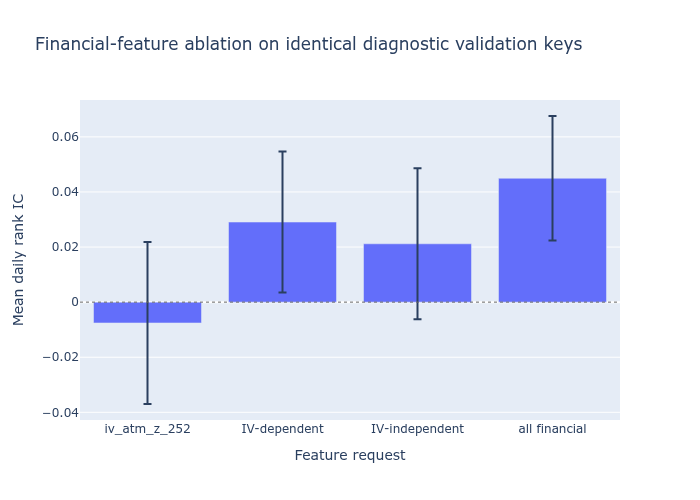

request,feature_count,mean_ic,hac_lower,hac_upper,hac_p_value,validation_days,key_digest
str,i64,f64,f64,f64,f64,i64,str
"""iv_atm_z_252""",1,-0.007568,-0.036984,0.021848,0.613434,492,"""73973337d28aa575"""
"""IV-dependent""",31,0.029081,0.003483,0.054678,0.026052,492,"""73973337d28aa575"""
"""IV-independent""",16,0.021178,-0.006242,0.048599,0.129771,492,"""73973337d28aa575"""
"""all financial""",47,0.044974,0.022369,0.06758,0.000106,492,"""73973337d28aa575"""


In [6]:
ablation = pl.DataFrame(
    [
        {"request": name, **summarize_ablation(features)}
        for name, features in ablation_requests.items()
    ]
)
if ablation.get_column("key_digest").n_unique() != 1:
    raise RuntimeError("ablation requests do not share exact validation coverage")

fig = go.Figure(
    go.Bar(
        x=ablation.get_column("request").to_list(),
        y=ablation.get_column("mean_ic").to_list(),
        error_y={
            "type": "data",
            "symmetric": False,
            "array": (ablation["hac_upper"] - ablation["mean_ic"]).to_list(),
            "arrayminus": (ablation["mean_ic"] - ablation["hac_lower"]).to_list(),
        },
        hovertemplate="%{x}<br>validation IC %{y:+.4f}<extra></extra>",
    )
)
fig.add_hline(y=0, line_width=1, line_dash="dot", line_color="#666666")
fig.update_layout(
    title="Financial-feature ablation on identical diagnostic validation keys",
    xaxis_title="Feature request",
    yaxis_title="Mean daily rank IC",
)
fig.show()
ablation

## IV lag decay

In [7]:
validation = pl.concat(
    [
        dataset.filter(
            pl.col("timestamp")
            .cast(pl.Date)
            .is_between(
                pl.lit(split["val_start"]).cast(pl.Date),
                pl.lit(split["val_end"]).cast(pl.Date),
                closed="both",
            )
        )
        for split in splits
    ]
).unique(subset=join_keys)


def mean_daily_ic(frame: pl.DataFrame, feature: str, target: str) -> float:
    panel = frame.select(
        pl.col("timestamp"),
        pl.col("symbol"),
        pl.col(feature).alias("y_score"),
        pl.col(target).alias("y_true"),
    ).drop_nulls()
    daily = daily_ic(
        panel,
        pred_col="y_score",
        ret_col="y_true",
        min_symbols_per_date=MIN_SYMBOLS_PER_DATE,
        described_as=f"{feature!r} against {target!r}",
    )
    mean_ic = daily.select(pl.col("ic").mean()).item()
    return float(mean_ic)

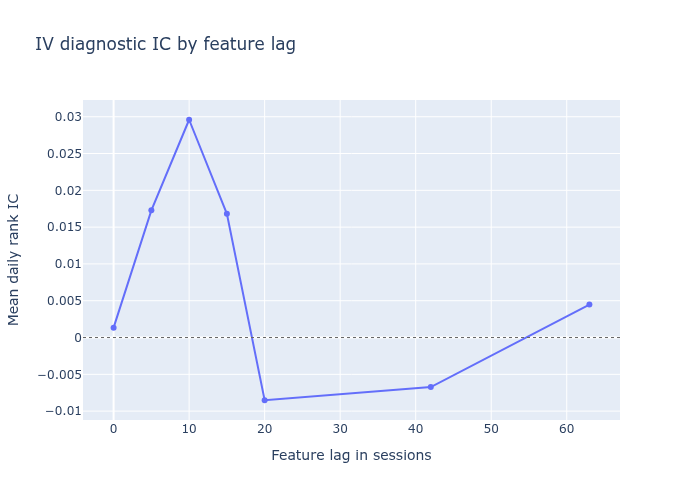

lag_sessions,mean_ic,iv_autocorrelation
i64,f64,f64
0,0.001342,1.0
5,0.017278,0.642242
10,0.029592,0.434535
15,0.016813,0.289103
20,-0.008524,0.181107
42,-0.006732,0.004816
63,0.004481,-0.017238


In [8]:
lags = (0, 5, 10, 15, 20, 42, 63)
lag_panel = validation.select("timestamp", "symbol", "iv_atm_z_252", DIAGNOSTIC_LABEL).sort(
    "symbol", "timestamp"
)
lag_rows = []
for lag in lags:
    shifted = lag_panel.with_columns(
        pl.col("iv_atm_z_252").shift(lag).over("symbol").alias("iv_lagged")
    )
    autocorrelation = (
        1.0
        if lag == 0
        else shifted.drop_nulls().select(pl.corr("iv_atm_z_252", "iv_lagged")).item()
    )
    lag_rows.append(
        {
            "lag_sessions": lag,
            "mean_ic": mean_daily_ic(shifted, "iv_lagged", DIAGNOSTIC_LABEL),
            "iv_autocorrelation": autocorrelation,
        }
    )
lag_results = pl.DataFrame(lag_rows)

fig = go.Figure(
    go.Scatter(
        x=lag_results.get_column("lag_sessions").to_list(),
        y=lag_results.get_column("mean_ic").to_list(),
        mode="lines+markers",
        customdata=lag_results.get_column("iv_autocorrelation").to_list(),
        hovertemplate=(
            "lag %{x} sessions<br>validation IC %{y:+.4f}"
            "<br>IV autocorrelation %{customdata:.3f}<extra></extra>"
        ),
    )
)
fig.add_hline(y=0, line_width=1, line_dash="dot", line_color="#666666")
fig.update_layout(
    title="IV diagnostic IC by feature lag",
    xaxis_title="Feature lag in sessions",
    yaxis_title="Mean daily rank IC",
)
fig.show()
lag_results

## Return decomposition

The same validation rows compare the delta-hedged label, the unhedged label, and their difference.

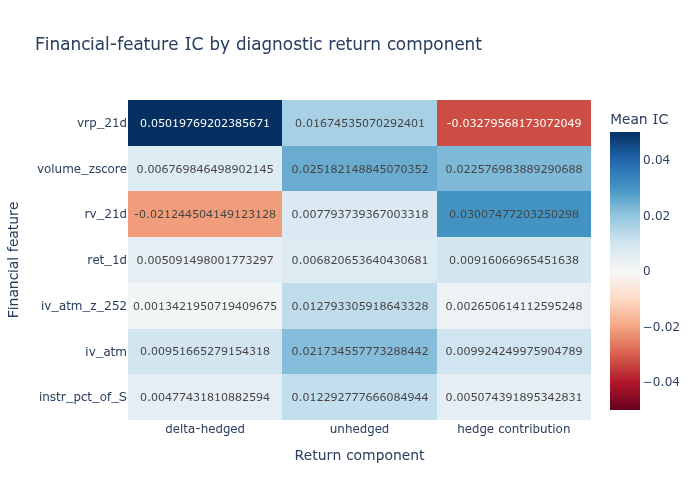

feature,target,mean_ic
str,str,f64
"""iv_atm_z_252""","""delta-hedged""",0.001342
"""iv_atm_z_252""","""unhedged""",0.012793
"""iv_atm_z_252""","""hedge contribution""",0.002651
"""vrp_21d""","""delta-hedged""",0.050198
"""vrp_21d""","""unhedged""",0.016745
…,…,…
"""rv_21d""","""unhedged""",0.007794
"""rv_21d""","""hedge contribution""",0.030075
"""volume_zscore""","""delta-hedged""",0.00677


In [9]:
decomposition = validation.join(
    unhedged_label.rename({UNHEDGED_LABEL: "unhedged_return"}),
    on=join_keys,
    how="inner",
    validate="1:1",
).with_columns((pl.col("unhedged_return") - pl.col(DIAGNOSTIC_LABEL)).alias("hedge_contribution"))
decomposition_features = (
    "iv_atm_z_252",
    "vrp_21d",
    "iv_atm",
    "instr_pct_of_S",
    "ret_1d",
    "rv_21d",
    "volume_zscore",
)
decomposition_targets = {
    "delta-hedged": DIAGNOSTIC_LABEL,
    "unhedged": "unhedged_return",
    "hedge contribution": "hedge_contribution",
}
decomposition_ic = pl.DataFrame(
    [
        {
            "feature": feature,
            "target": target_name,
            "mean_ic": mean_daily_ic(decomposition, feature, target),
        }
        for feature in decomposition_features
        for target_name, target in decomposition_targets.items()
    ]
)

heatmap = decomposition_ic.pivot(
    on="target",
    index="feature",
    values="mean_ic",
    aggregate_function="first",
).sort("feature")
target_columns = list(decomposition_targets)
fig = go.Figure(
    go.Heatmap(
        z=heatmap.select(target_columns).to_numpy(),
        x=target_columns,
        y=heatmap.get_column("feature").to_list(),
        colorscale="RdBu",
        zmid=0,
        texttemplate="%{z:+.3f}",
        colorbar={"title": "Mean IC"},
    )
)
fig.update_layout(
    title="Financial-feature IC by diagnostic return component",
    xaxis_title="Return component",
    yaxis_title="Financial feature",
)
fig.show()
decomposition_ic

## Training-only feature dimensionality

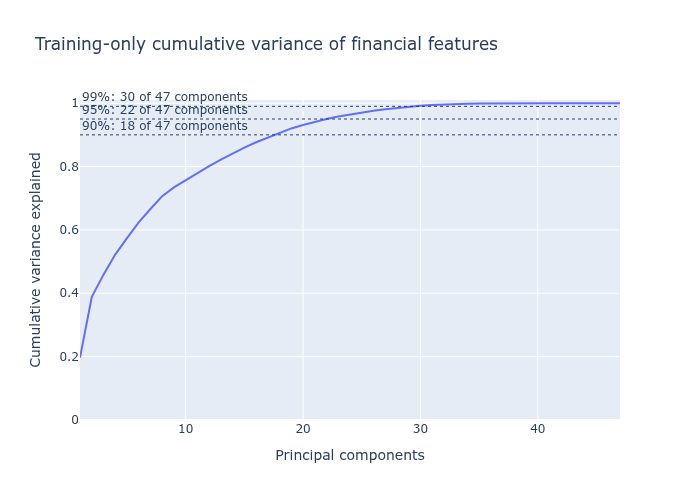

In [10]:
pca_fold = prepare_cv_folds(
    dataset.to_pandas(),
    select_folds(splits, [0]),
    feature_names,
    DIAGNOSTIC_LABEL,
    "timestamp",
    "symbol",
)[0]
pca = PCA().fit(pca_fold["X_train"])
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

fig = go.Figure(
    go.Scatter(
        x=list(range(1, len(cumulative_variance) + 1)),
        y=cumulative_variance,
        mode="lines",
        hovertemplate="%{x} components<br>cumulative variance %{y:.1%}<extra></extra>",
    )
)
for threshold in (0.90, 0.95, 0.99):
    components = int(np.searchsorted(cumulative_variance, threshold)) + 1
    fig.add_hline(
        y=threshold,
        line_width=1,
        line_dash="dot",
        annotation_text=f"{threshold:.0%}: {components} of {len(feature_names)} components",
        annotation_position="top left",
    )
fig.update_layout(
    title="Training-only cumulative variance of financial features",
    xaxis_title="Principal components",
    yaxis_title="Cumulative variance explained",
    yaxis_range=[0, 1.01],
)
fig.show()

These result tables and figures describe validation-only mechanism checks for the diagnostic
label. They do not enter model selection, strategy selection, or the locked holdout.